## Lab7

In this assignment we compare the performance of various classifiers on a two-class data set where the two classes cannot be linearly separated.

In [1]:
# Import your libraries here
import matplotlib.pyplot as plt
import sklearn.model_selection as skm

from matplotlib.pyplot import subplots

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import make_moons

from ISLP import confusion_table
from ISLP.svm import plot as plot_svm

**a) Generate a simulated two-class data set with 100 observations per class and
two features in which there is a visible but non-linear separation between
the two classes. Use the `make_moons` function from from `sklearn.datasets`:**

**`X, y = make_moons(n_samples=200, noise=0.25, random_state=1)`**

**Next, split the dataset equally into a training and a test set using the `train_test_split` function from `sklearn.model_selection`. Use `test_size=0.5` and `random_state=1` to ensure reproducibility.**

**To make sure that both the training and test sets contain approximately the same proportion of observations from each class, include the argument `stratify=y`. This ensures that if the original dataset is balanced (e.g., 50% per class) or imbalanced (e.g. 90%-10%), the same class ratios are preserved in both the training and test sets.**

In [2]:
X, y = make_moons(n_samples=200, noise=0.25, random_state=1)
X_train, X_test, y_train, y_test = skm.train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)


**b) Apply a support vector classifier to the train data. Perform K-Fold cross-validation for various values of C with k=5. Instead of the basic `KFold` splitter, use `StratifiedKFold` from `sklearn.model_selection`. It works like `KFold`, but it also ensures that each fold contains approximately the same proportion of observations from each class as in the full dataset, which is especially important when working with imbalanced data, as it guarantees that all training and validation folds are representative of the overall class distribution.**

**Do the following:**
- **Find the *train accuracy* of the best model**
- **Display the confusion table based on the train set.**
- **Make a plot of the observations and the decision boundary.**

Best C for linear SVM: 10
Train accuracy (CV) for linear SVM: 0.8429
Confusion table for linear SVM (train set):
Truth       0   1
Predicted        
0          59  10
1          11  60


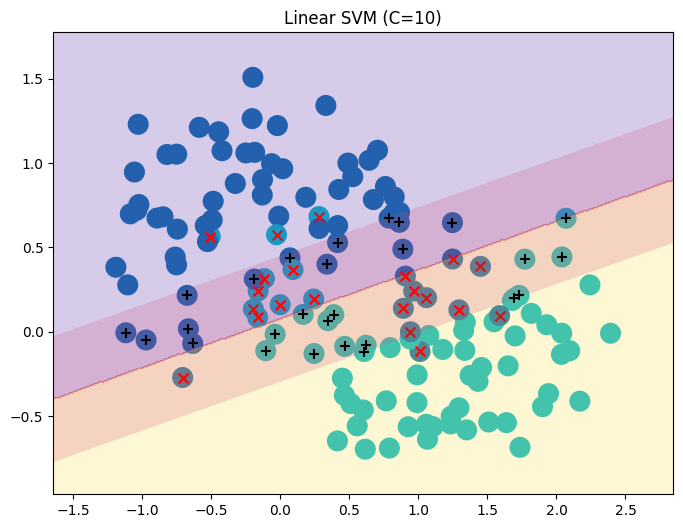

In [3]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
svm_linear = SVC(kernel='linear', random_state=1)

stratified_kfold = skm.StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid_linear = skm.GridSearchCV(
    svm_linear,
    param_grid,
    cv=stratified_kfold,
    scoring='accuracy',
    return_train_score=True
    )

grid_linear.fit(X_train, y_train)

best_linear = grid_linear.best_estimator_

train_accuracy_linear = grid_linear.best_score_
print(f"Best C for linear SVM: {grid_linear.best_params_['C']}")
print(f"Train accuracy (CV) for linear SVM: {train_accuracy_linear:.4f}")

y_train_pred_linear = best_linear.predict(X_train)

confusion_train_linear = confusion_table(y_train_pred_linear, y_train)
print("Confusion table for linear SVM (train set):")
print(confusion_train_linear)

fig, ax = subplots(figsize=(8,6))
plot_svm(X_train, y_train, best_linear, ax=ax)
ax.set_title(f'Linear SVM (C={grid_linear.best_params_['C']})')
plt.show()



**c) Repeat (b) for a support vector machine with a *polynomial kernel* (with degree greater than 1).**

Best C for polynomial SVM: 10
Best degree for polynomial SVM: 3
Train accuracy (CV) for polynomial SVM: 0.8714
Confusion table for polynomial SVM (train set):
Truth       0   1
Predicted        
0          57   4
1          13  66


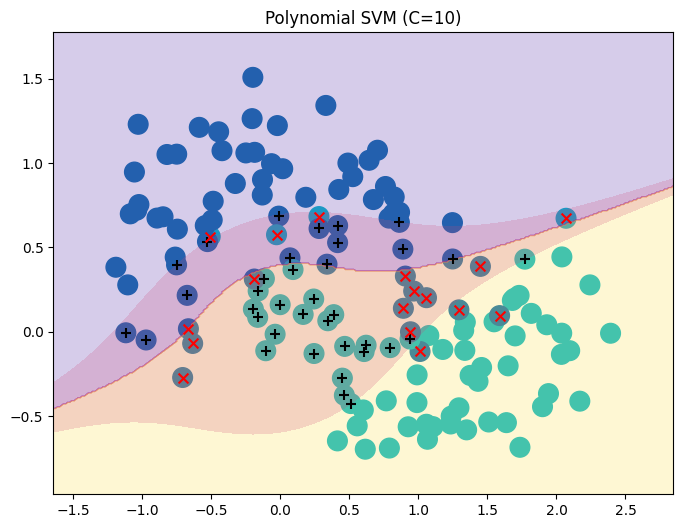

In [4]:
param_grid_poly = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'degree': [2, 3, 4]
}
svm_poly = SVC(kernel='poly', random_state=1)

grid_poly = skm.GridSearchCV(
    svm_poly,
    param_grid_poly,
    cv=stratified_kfold, # same as before
    scoring='accuracy',
    return_train_score=True
    )

grid_poly.fit(X_train, y_train)

best_poly = grid_poly.best_estimator_

train_accuracy_poly = grid_poly.best_score_
print(f"Best C for polynomial SVM: {grid_poly.best_params_['C']}")
print(f"Best degree for polynomial SVM: {grid_poly.best_params_['degree']}")
print(f"Train accuracy (CV) for polynomial SVM: {train_accuracy_poly:.4f}")

y_train_pred_poly = best_poly.predict(X_train)

confusion_train_poly = confusion_table(y_train_pred_poly, y_train)
print("Confusion table for polynomial SVM (train set):")
print(confusion_train_poly)

fig, ax = subplots(figsize=(8,6))
plot_svm(X_train, y_train, best_poly, ax=ax)
ax.set_title(f'Polynomial SVM (C={grid_poly.best_params_['C']})')
plt.show()

**d) Repeat (b) for a support vector machine with a *radial kernel*.**

Best C for radial SVM: 10
Best gamma for radial SVM: 1
Train accuracy (CV) for radial SVM: 0.9357
Confusion table for radial SVM (train set):
Truth       0   1
Predicted        
0          65   3
1           5  67


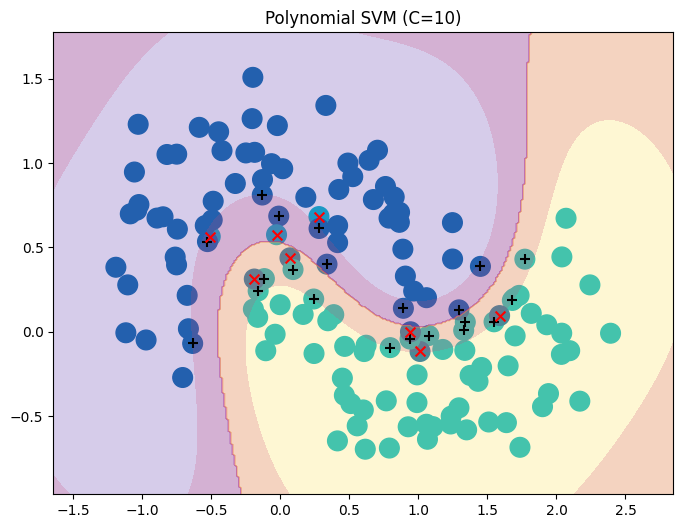

In [5]:
param_grid_radial = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'gamma': [0.1, 1, 10, 100]
}
svm_radial = SVC(kernel='rbf', random_state=1)

grid_radial = skm.GridSearchCV(
    svm_radial,
    param_grid_radial,
    cv=stratified_kfold, # same as before
    scoring='accuracy',
    return_train_score=True
    )

grid_radial.fit(X_train, y_train)

best_radial = grid_radial.best_estimator_

train_accuracy_radial = grid_radial.best_score_
print(f"Best C for radial SVM: {grid_radial.best_params_['C']}")
print(f"Best gamma for radial SVM: {grid_radial.best_params_['gamma']}")
print(f"Train accuracy (CV) for radial SVM: {train_accuracy_radial:.4f}")

y_train_pred_radial = best_radial.predict(X_train)

confusion_train_radial = confusion_table(y_train_pred_radial, y_train)
print("Confusion table for radial SVM (train set):")
print(confusion_train_radial)

fig, ax = subplots(figsize=(8,6))
plot_svm(X_train, y_train, best_radial, ax=ax)
ax.set_title(f'Polynomial SVM (C={grid_radial.best_params_['C']})')
plt.show()

**e) How do the models from (b)-(d) do on the *test data*? Make plots and report the test accuracies. Comment on your findings.**

Linear SVM - Test Confusion Matrix:
[[25  5]
 [ 4 26]]
Linear SVM - Test Accuracy: 0.8500

Polynomial SVM - Test Confusion Matrix:
[[25  5]
 [ 1 29]]
Polynomial SVM - Test Accuracy: 0.9000

Radial - Test Confusion Matrix:
[[29  1]
 [ 1 29]]
Radial - Test Accuracy: 0.9667



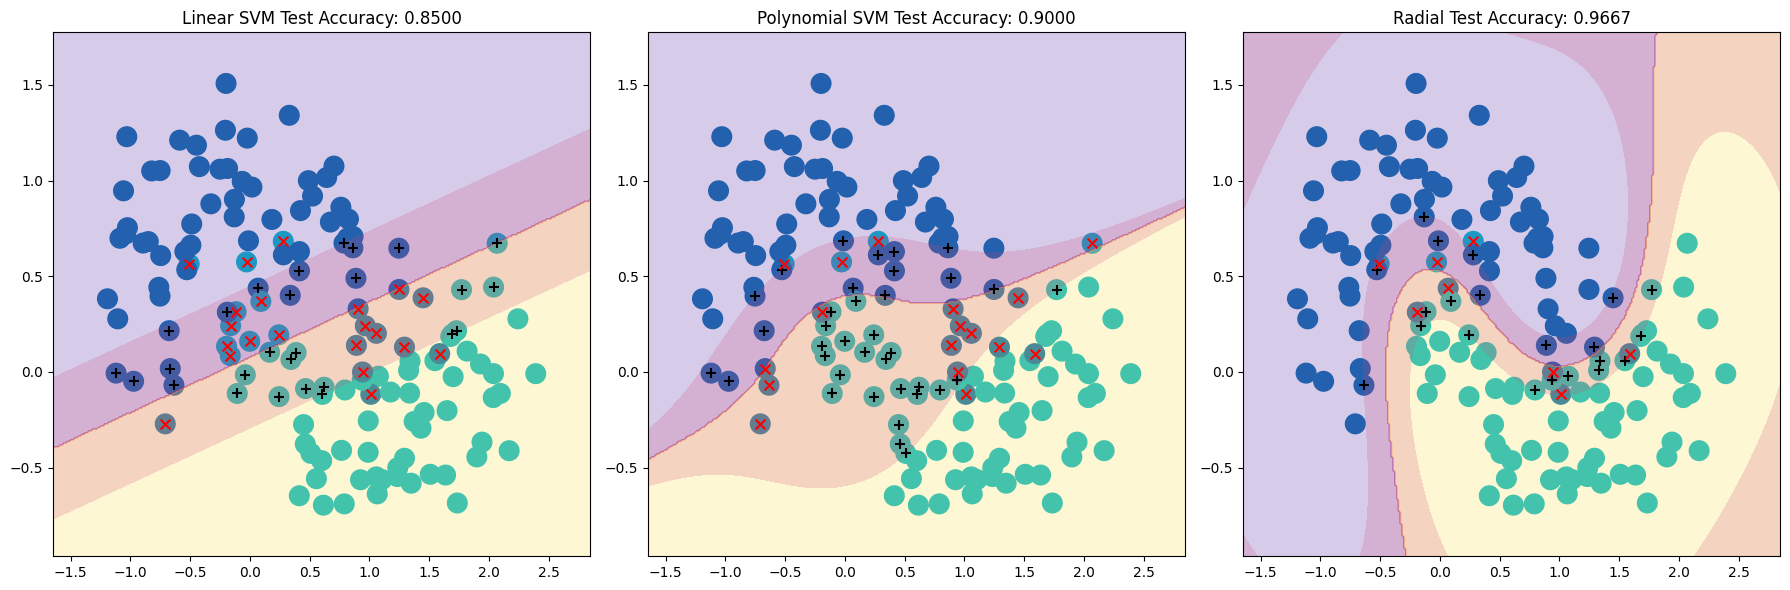


=== MODEL COMPARISON ===
Linear SVM: 0.8500
Polynomial SVM: 0.9000
Radial: 0.9667


In [6]:
models = {
    'Linear SVM': best_linear,
    'Polynomial SVM': best_poly,
    'Radial': best_radial
}

test_accuracies = {}
fig, axes = subplots(1,3, figsize=(18,6))

for ax, (name, model) in enumerate(models.items()):
    y_test_pred = model.predict(X_test)

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_accuracies[name] = test_accuracy

    plot_svm(X_train, y_train, model, ax=axes[ax])
    axes[ax].set_title(f'{name} Test Accuracy: {test_accuracy:.4f}')

    conf_matrix = confusion_matrix(y_test, y_test_pred)
    print(f"{name} - Test Confusion Matrix:")
    print(conf_matrix)
    print(f"{name} - Test Accuracy: {test_accuracy:.4f}\n")

plt.tight_layout()
plt.show()

print("\n=== MODEL COMPARISON ===")
for name, accuracy in test_accuracies.items():
    print(f"{name}: {accuracy:.4f}")

(Your comments here)

The best performing model was the SVM with the Radial kernel using a C of 10 and a gamma of 1 achieving an accuracy of 0.9667.
The medium performing model was the SVM with the Polynomial kernel using a C of 10 and a degree of 3 achieving an accuracy of 0.9000
The worst performing modewl was the SVM with the Linear kernel using a C of 10 achieving an accuracy of 0.8500.

One thing I noticed is that the testing accuracies (of the model with the highest accuracies) were consistently higher than the training accuracies accross all three models.